In [1]:
%run ../../setup_workspace.py # ../ means level up 


<Figure size 1500x500 with 0 Axes>

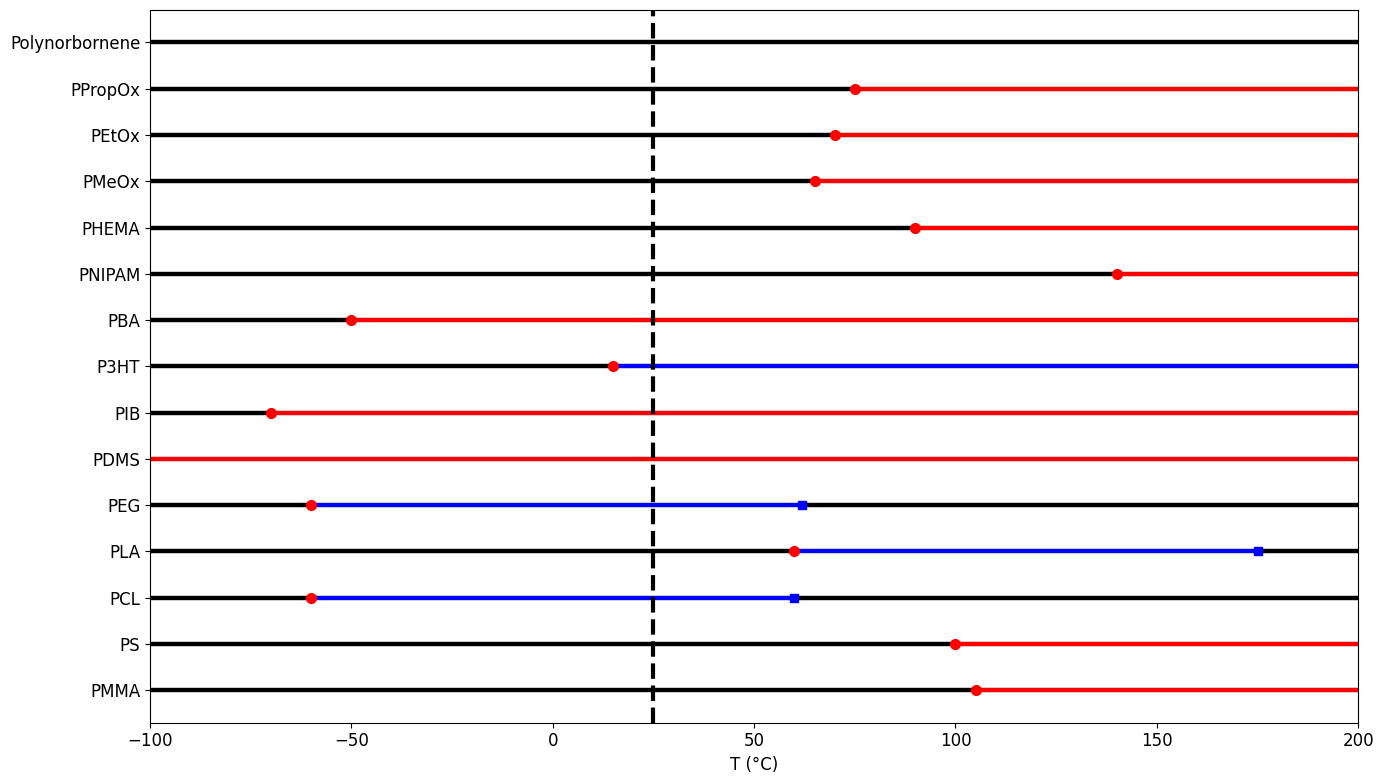

In [2]:
plt.figure(figsize=(15,5))
# Данные
polymers = ['PMMA', 'PS', 'PCL', 'PLA', 'PEG', 'PDMS', 'PIB', 
            'P3HT', 'PBA', 'PNIPAM', 'PHEMA', 'PMeOx', 'PEtOx', 
            'PPropOx', 'Polynorbornene']
Tg = [105, 100, -60, 60, -60, -123, -70, 15, -50, 140, 90, 65, 70, 75, 230]
Tm = [None, None, 60, 175, 62, None, None, 230, None, None, None, None, None, None, None]

fig, ax = plt.subplots(figsize=(14, 8))

for i, (p, tg, tm) in enumerate(zip(polymers, Tg, Tm)):
    # Серая линия-фон (вся от -100 до 200)
    ax.hlines(y=i, xmin=-100, xmax=200, colors='lightgray', linewidth=4, zorder=0)
    
    # Определяем диапазоны и их цвета
    # Стекло: от -100 до Tg (черный)
    if tg > -100:
        ax.hlines(y=i, xmin=-100, xmax=tg, colors='black', linewidth=3, zorder=1)
    
    # Промежуточное состояние: от Tg до Tm или до 200
    if tm is not None:
        # Кристаллический (синий)
        ax.hlines(y=i, xmin=tg, xmax=tm, colors='blue', linewidth=3, zorder=1)
        # Расплав после Tm: от Tm до 200 (черный, стеклообразный при охлаждении)
        if tm < 200:
            ax.hlines(y=i, xmin=tm, xmax=200, colors='black', linewidth=3, zorder=1)
    else:
        # Аморфный: от Tg до 200 (красный, если Tg ниже комнатной, иначе черный)
        # Но для единообразия: если полимер аморфный и Tg < 200, то выше Tg он красный
        if tg < 200:
            ax.hlines(y=i, xmin=tg, xmax=200, colors='red', linewidth=3, zorder=1)
    
    # Точка Tg
    ax.plot(tg, i, 'o', color='red', markersize=7, zorder=2)
    # Точка Tm
    if tm is not None:
        ax.plot(tm, i, 's', color='blue', markersize=6, zorder=2)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='Стекло'),
    Patch(facecolor='blue', edgecolor='blue', label='Кристаллический'),
    Patch(facecolor='red', edgecolor='red', label='Аморфный / Высокоэластический')
]
# ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.axvline(x=25, linestyle='--', linewidth=3, color='black')

ax.set_yticks(range(len(polymers)))
ax.set_yticklabels(polymers)
ax.set_xlabel('T (°C)')
ax.set_xlim(-100, 200)
plt.tight_layout()
plt.show()

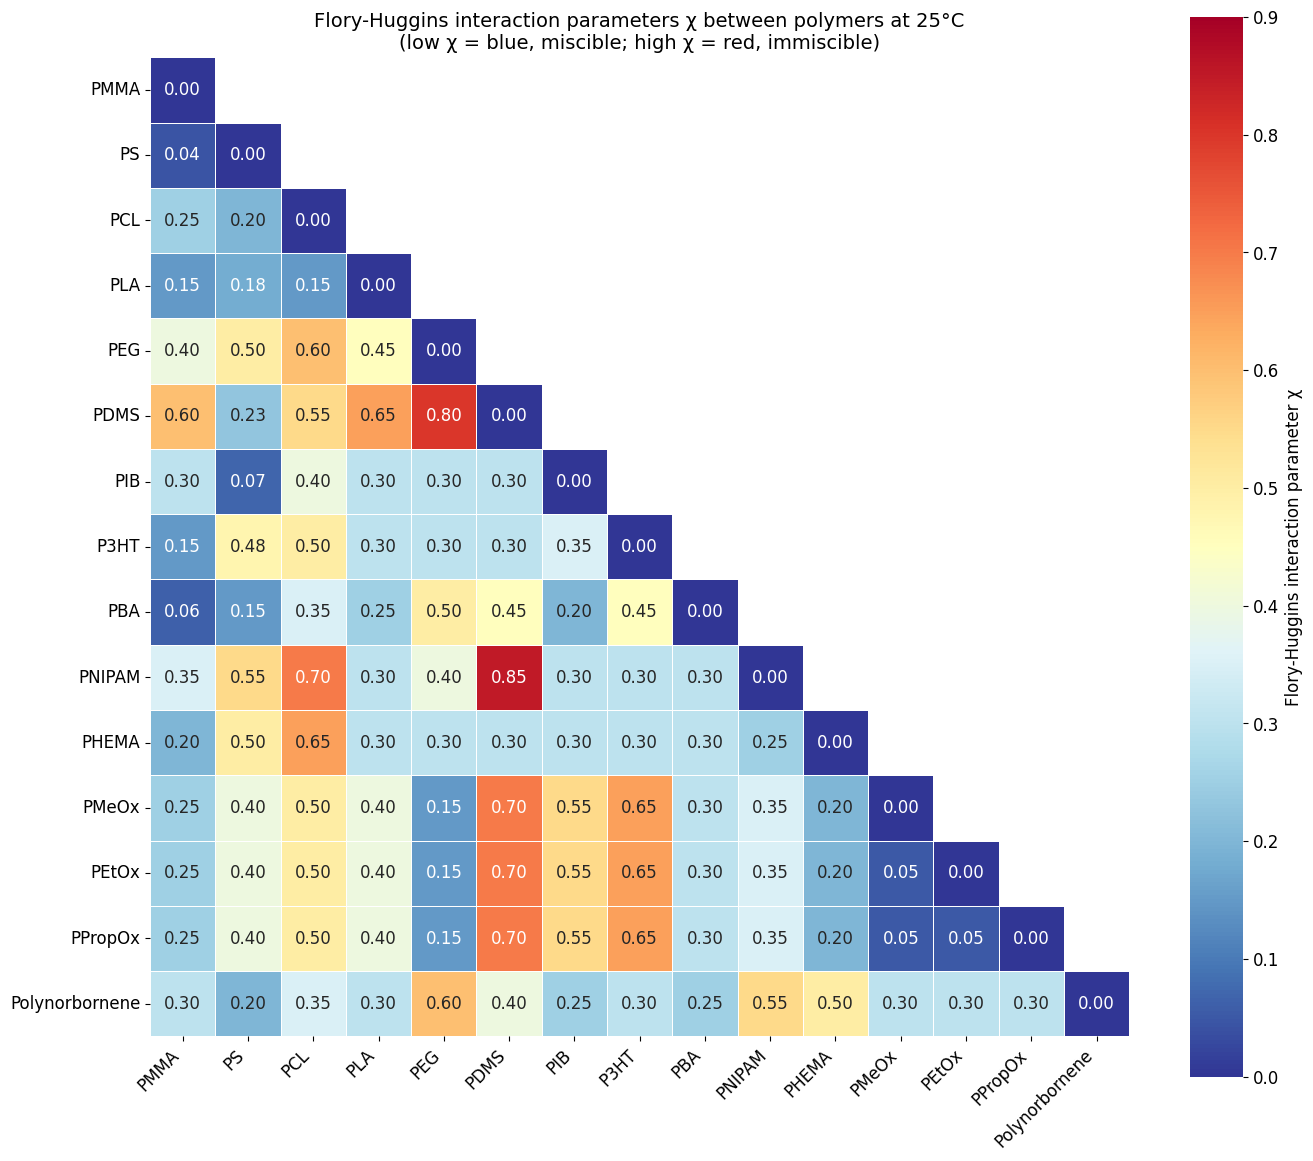


=== Chi statistics ===
PMMA            → min χ = 0.04 (with PS             ), max χ = 0.60 (with PDMS           )
PS              → min χ = 0.04 (with PMMA           ), max χ = 0.55 (with PNIPAM         )
PCL             → min χ = 0.15 (with PLA            ), max χ = 0.70 (with PNIPAM         )
PLA             → min χ = 0.15 (with PMMA           ), max χ = 0.65 (with PDMS           )
PEG             → min χ = 0.15 (with PMeOx          ), max χ = 0.80 (with PDMS           )
PDMS            → min χ = 0.23 (with PS             ), max χ = 0.85 (with PNIPAM         )
PIB             → min χ = 0.07 (with PS             ), max χ = 0.55 (with PMeOx          )
P3HT            → min χ = 0.15 (with PMMA           ), max χ = 0.65 (with PMeOx          )
PBA             → min χ = 0.06 (with PMMA           ), max χ = 0.50 (with PEG            )
PNIPAM          → min χ = 0.25 (with PHEMA          ), max χ = 0.85 (with PDMS           )
PHEMA           → min χ = 0.20 (with PMMA           ), max χ = 0.6

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Polymers
polymers = ['PMMA', 'PS', 'PCL', 'PLA', 'PEG', 'PDMS', 'PIB', 
            'P3HT', 'PBA', 'PNIPAM', 'PHEMA', 'PMeOx', 'PEtOx', 
            'PPropOx', 'Polynorbornene']

n = len(polymers)

# Chi matrix (approximate, at 25°C)
# Diagonal = 0 (polymer with itself)
chi = np.zeros((n, n))

# Fill the matrix based on data and estimates
for i in range(n):
    for j in range(n):
        if i == j:
            chi[i, j] = 0
        elif i < j:
            # PMMA (0)
            if polymers[i] == 'PMMA' and polymers[j] == 'PS':
                chi[i, j] = 0.043
            elif polymers[i] == 'PMMA' and polymers[j] == 'PCL':
                chi[i, j] = 0.25
            elif polymers[i] == 'PMMA' and polymers[j] == 'PLA':
                chi[i, j] = 0.15
            elif polymers[i] == 'PMMA' and polymers[j] == 'PEG':
                chi[i, j] = 0.40
            elif polymers[i] == 'PMMA' and polymers[j] == 'PDMS':
                chi[i, j] = 0.60
            elif polymers[i] == 'PMMA' and polymers[j] == 'PBA':
                chi[i, j] = 0.06
            elif polymers[i] == 'PMMA' and polymers[j] == 'P3HT':
                chi[i, j] = 0.15
            elif polymers[i] == 'PMMA' and polymers[j] == 'PNIPAM':
                chi[i, j] = 0.35
            elif polymers[i] == 'PMMA' and polymers[j] == 'PHEMA':
                chi[i, j] = 0.20
            elif polymers[i] == 'PMMA' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.25
            elif polymers[i] == 'PMMA' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.30
            
            # PS (1)
            elif polymers[i] == 'PS' and polymers[j] == 'PCL':
                chi[i, j] = 0.20
            elif polymers[i] == 'PS' and polymers[j] == 'PLA':
                chi[i, j] = 0.18
            elif polymers[i] == 'PS' and polymers[j] == 'PEG':
                chi[i, j] = 0.50
            elif polymers[i] == 'PS' and polymers[j] == 'PDMS':
                chi[i, j] = 0.23
            elif polymers[i] == 'PS' and polymers[j] == 'PIB':
                chi[i, j] = 0.07
            elif polymers[i] == 'PS' and polymers[j] == 'P3HT':
                chi[i, j] = 0.48
            elif polymers[i] == 'PS' and polymers[j] == 'PBA':
                chi[i, j] = 0.15
            elif polymers[i] == 'PS' and polymers[j] == 'PNIPAM':
                chi[i, j] = 0.55
            elif polymers[i] == 'PS' and polymers[j] == 'PHEMA':
                chi[i, j] = 0.50
            elif polymers[i] == 'PS' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.40
            elif polymers[i] == 'PS' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.20
            
            # PCL (2)
            elif polymers[i] == 'PCL' and polymers[j] == 'PLA':
                chi[i, j] = 0.15
            elif polymers[i] == 'PCL' and polymers[j] == 'PEG':
                chi[i, j] = 0.60
            elif polymers[i] == 'PCL' and polymers[j] == 'PDMS':
                chi[i, j] = 0.55
            elif polymers[i] == 'PCL' and polymers[j] == 'PIB':
                chi[i, j] = 0.40
            elif polymers[i] == 'PCL' and polymers[j] == 'P3HT':
                chi[i, j] = 0.50
            elif polymers[i] == 'PCL' and polymers[j] == 'PBA':
                chi[i, j] = 0.35
            elif polymers[i] == 'PCL' and polymers[j] == 'PNIPAM':
                chi[i, j] = 0.70
            elif polymers[i] == 'PCL' and polymers[j] == 'PHEMA':
                chi[i, j] = 0.65
            elif polymers[i] == 'PCL' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.50
            elif polymers[i] == 'PCL' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.35
            
            # PLA (3)
            elif polymers[i] == 'PLA' and polymers[j] == 'PEG':
                chi[i, j] = 0.45
            elif polymers[i] == 'PLA' and polymers[j] == 'PDMS':
                chi[i, j] = 0.65
            elif polymers[i] == 'PLA' and polymers[j] == 'PBA':
                chi[i, j] = 0.25
            elif polymers[i] == 'PLA' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.40
            elif polymers[i] == 'PLA' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.30
            
            # PEG (4)
            elif polymers[i] == 'PEG' and polymers[j] == 'PDMS':
                chi[i, j] = 0.80
            elif polymers[i] == 'PEG' and polymers[j] == 'PBA':
                chi[i, j] = 0.50
            elif polymers[i] == 'PEG' and polymers[j] == 'PNIPAM':
                chi[i, j] = 0.40
            elif polymers[i] == 'PEG' and polymers[j] == 'PHEMA':
                chi[i, j] = 0.30
            elif polymers[i] == 'PEG' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.15
            elif polymers[i] == 'PEG' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.60
            
            # PDMS (5)
            elif polymers[i] == 'PDMS' and polymers[j] == 'PBA':
                chi[i, j] = 0.45
            elif polymers[i] == 'PDMS' and polymers[j] == 'PNIPAM':
                chi[i, j] = 0.85
            elif polymers[i] == 'PDMS' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.70
            elif polymers[i] == 'PDMS' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.40
            
            # PIB (6)
            elif polymers[i] == 'PIB' and polymers[j] == 'P3HT':
                chi[i, j] = 0.35
            elif polymers[i] == 'PIB' and polymers[j] == 'PBA':
                chi[i, j] = 0.20
            elif polymers[i] == 'PIB' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.55
            elif polymers[i] == 'PIB' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.25
            
            # P3HT (7)
            elif polymers[i] == 'P3HT' and polymers[j] == 'PBA':
                chi[i, j] = 0.45
            elif polymers[i] == 'P3HT' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.65
            elif polymers[i] == 'P3HT' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.30
            
            # PBA (8)
            elif polymers[i] == 'PBA' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.30
            elif polymers[i] == 'PBA' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.25
            
            # PNIPAM (9)
            elif polymers[i] == 'PNIPAM' and polymers[j] == 'PHEMA':
                chi[i, j] = 0.25
            elif polymers[i] == 'PNIPAM' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.35
            elif polymers[i] == 'PNIPAM' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.55
            
            # PHEMA (10)
            elif polymers[i] == 'PHEMA' and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.20
            elif polymers[i] == 'PHEMA' and polymers[j] == 'Polynorbornene':
                chi[i, j] = 0.50
            
            # POx among themselves (11-13)
            elif polymers[i] in ['PMeOx', 'PEtOx', 'PPropOx'] and polymers[j] in ['PMeOx', 'PEtOx', 'PPropOx']:
                chi[i, j] = 0.05
            
            # Default value
            else:
                chi[i, j] = 0.30
            
            # Symmetric fill
            chi[j, i] = chi[i, j]

# Create DataFrame
df_chi = pd.DataFrame(chi, index=polymers, columns=polymers)

# Plot heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(df_chi, dtype=bool), k=1)

sns.heatmap(df_chi, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlBu_r',
            vmin=0,
            vmax=0.9,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Flory-Huggins interaction parameter χ'},
            mask=mask)

plt.title('Flory-Huggins interaction parameters χ between polymers at 25°C\n(low χ = blue, miscible; high χ = red, immiscible)',
          fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Chi statistics ===")
for p in polymers:
    row = df_chi.loc[p]
    row_without_self = row[row.index != p]
    min_pair = row_without_self.idxmin()
    max_pair = row_without_self.idxmax()
    print(f"{p:15} → min χ = {row_without_self.min():.2f} (with {min_pair:15}), max χ = {row_without_self.max():.2f} (with {max_pair:15})")

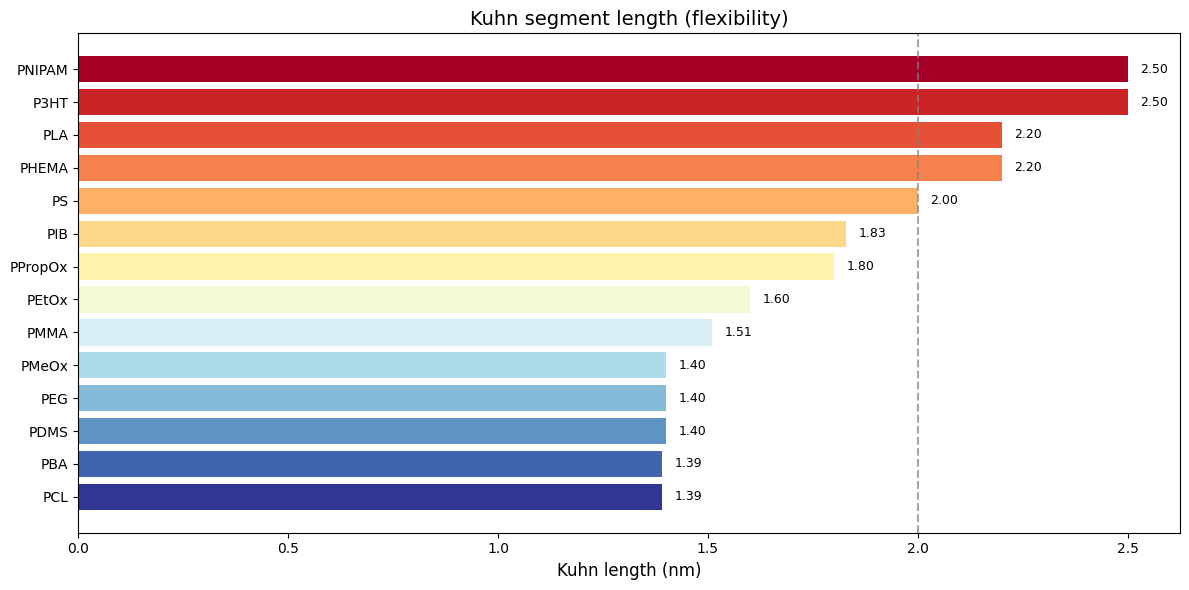

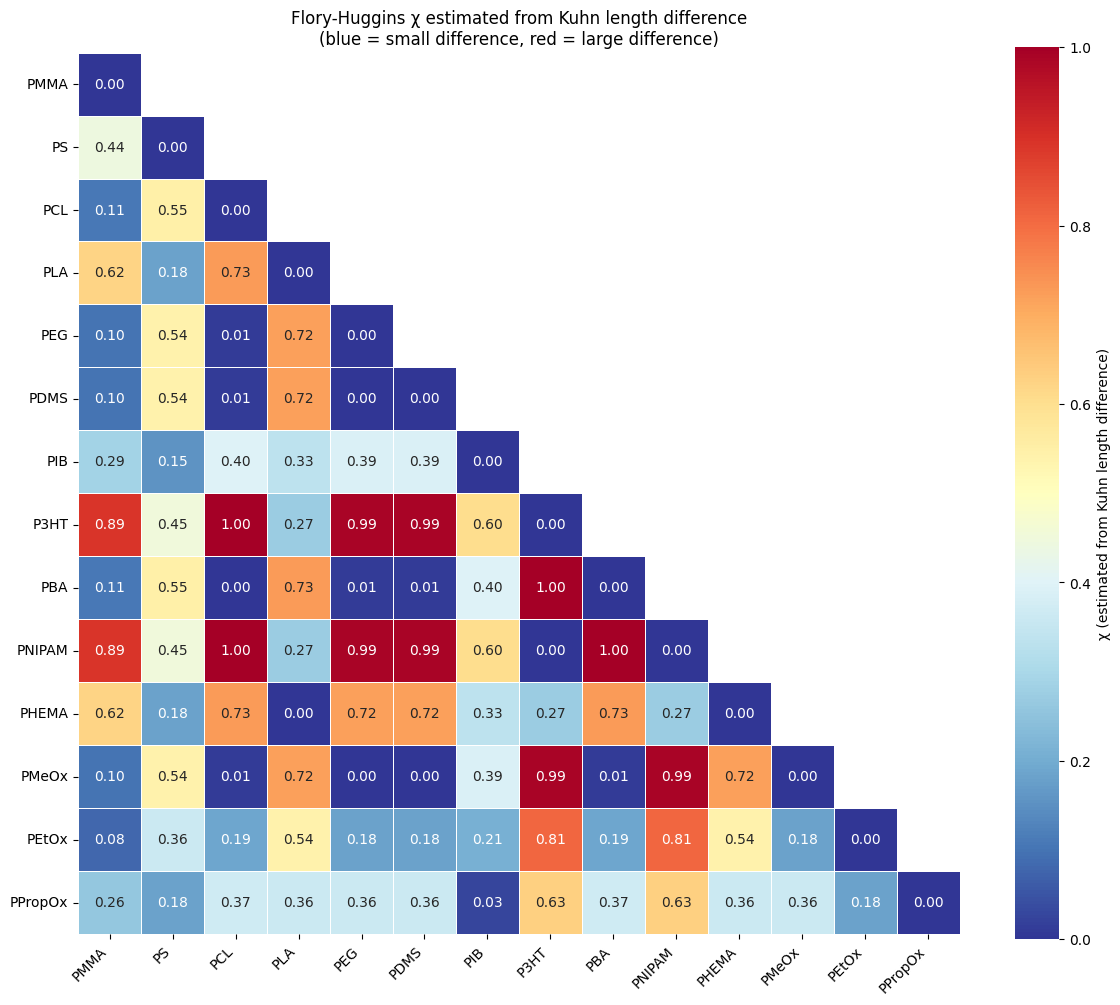

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# DATA: KUHN LENGTH (b) IN nm (without polynorbornene)
# =========================================================
polymers = ['PMMA', 'PS', 'PCL', 'PLA', 'PEG', 'PDMS', 'PIB', 
            'P3HT', 'PBA', 'PNIPAM', 'PHEMA', 'PMeOx', 'PEtOx', 'PPropOx']

b_values = [
    1.51,   # PMMA
    2.00,   # PS
    1.39,   # PCL
    2.20,   # PLA
    1.40,   # PEG
    1.40,   # PDMS
    1.83,   # PIB
    2.50,   # P3HT
    1.39,   # PBA
    2.50,   # PNIPAM
    2.20,   # PHEMA
    1.40,   # PMeOx
    1.60,   # PEtOx
    1.80    # PPropOx
]

# =========================================================
# BAR CHART: KUHN LENGTH
# =========================================================
df_b = pd.DataFrame({'Polymer': polymers, 'Kuhn_length_nm': b_values})
df_b_sorted = df_b.sort_values('Kuhn_length_nm', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(df_b_sorted)))
bars = ax.barh(df_b_sorted['Polymer'], df_b_sorted['Kuhn_length_nm'], color=colors)
ax.set_xlabel('Kuhn length (nm)', fontsize=12)
ax.set_title('Kuhn segment length (flexibility)', fontsize=14)
ax.axvline(x=2.0, color='gray', linestyle='--', alpha=0.7)
for bar, b_val in zip(bars, df_b_sorted['Kuhn_length_nm']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2, 
            f'{b_val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# =========================================================
# HEATMAP: CHI FROM KUHN LENGTH DIFFERENCE
# =========================================================
n = len(polymers)
chi = np.zeros((n, n))
b_arr = np.array(b_values)
max_diff = max(b_arr) - min(b_arr)

for i in range(n):
    for j in range(n):
        if i == j:
            chi[i, j] = 0
        else:
            diff = abs(b_arr[i] - b_arr[j])
            chi[i, j] = diff / max_diff
            chi[j, i] = chi[i, j]

df_chi = pd.DataFrame(chi, index=polymers, columns=polymers)

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df_chi, dtype=bool), k=1)
sns.heatmap(df_chi, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlBu_r',
            vmin=0,
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'χ (estimated from Kuhn length difference)'},
            mask=mask)
plt.title('Flory-Huggins χ estimated from Kuhn length difference\n(blue = small difference, red = large difference)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()